In [30]:
# Cell 1
import pandas as pd
import numpy as np
import gzip
import json
import urllib.request
import matplotlib.pyplot as plt

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
from sklearn.model_selection import train_test_split

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [31]:
# Cell 2
url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz"
file_name = "All_Beauty.jsonl.gz"

print("Downloading dataset (this may take a moment)...")
urllib.request.urlretrieve(url, file_name)
print("Download complete.")

print("Parsing JSONL.GZ file...")
data = []

# Open the compressed file and read line by line
with gzip.open(file_name, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        # Limiting to 100,000 rows to prevent RAM overload.
        # Remove or increase this limit if your machine has high memory.
        #if i >= 100000:
        #    break
        data.append(json.loads(line))

df = pd.DataFrame(data)
print(f"Loaded {len(df)} records.")
df.head(3)

Download complete.
Parsing JSONL.GZ file...
Loaded 701528 records.


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True


In [32]:
# Cell 3 (Updated with Balancing Pipeline and 3-Star Count)
from sklearn.utils import resample
import pandas as pd

def preprocess_and_balance_data(df, random_seed=42):
    # Combine title and text to give models maximum context
    df = df.copy()
    df['full_text'] = df['title'].fillna('') + " " + df['text'].fillna('')

    # Drop rows that are completely empty
    df = df[df['full_text'].str.strip() != ""]

    # Count how many 3-star reviews exist before dropping them
    num_dropped_3_star = len(df[df['rating'] == 3.0])

    # Filter out 3-star reviews for binary classification
    df = df[df['rating'] != 3.0]

    # Create binary sentiment labels (4 & 5 stars -> 1, 1 & 2 stars -> 0)
    df['sentiment'] = df['rating'].apply(lambda x: 1 if x > 3 else 0)

    # Separate the reviews into majority and minority classes
    positive_reviews = df[df['sentiment'] == 1]
    negative_reviews = df[df['sentiment'] == 0]

    min_class_size = min(len(positive_reviews), len(negative_reviews))

    # Downsample the classes to match the minimum class size
    pos_downsampled = resample(positive_reviews,
                               replace=False,
                               n_samples=min_class_size,
                               random_state=random_seed)

    neg_downsampled = resample(negative_reviews,
                               replace=False,
                               n_samples=min_class_size,
                               random_state=random_seed)

    # Combine the downsampled classes back together
    balanced_df = pd.concat([pos_downsampled, neg_downsampled])

    # Shuffle the dataset
    balanced_df = balanced_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)

    # We now return the dropped count as well
    return balanced_df, pos_downsampled, neg_downsampled, num_dropped_3_star

print("Balancing the dataset...")
balanced_df, pos_df, neg_df, dropped_count = preprocess_and_balance_data(df)

print(f"Dataset balanced successfully!")
print(f"Total 3-star (neutral) reviews dropped: {dropped_count}")
print(f"Total reviews kept for training: {len(balanced_df)}")
print(f"Positive reviews: {len(pos_df)} | Negative reviews: {len(neg_df)}")

# Extract the features (X) and labels (y) for Cell 4 to use
texts = balanced_df['full_text'].values
labels = balanced_df['sentiment'].values

Balancing the dataset...
Dataset balanced successfully!
Total 3-star (neutral) reviews dropped: 56307
Total reviews kept for training: 290228
Positive reviews: 145114 | Negative reviews: 145114


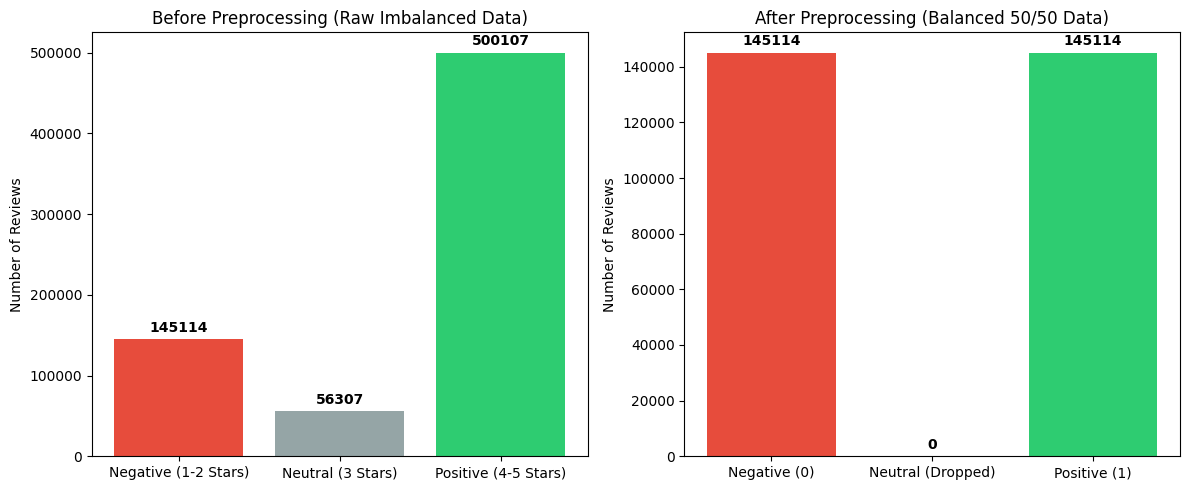

In [33]:
# Cell 3.5 (Visualization of Class Distributions)
import matplotlib.pyplot as plt

# --- Calculate "Before" Distribution from raw df ---
# Grouping the raw 1-5 star ratings into our 3 categories
raw_neg = len(df[df['rating'].isin([1.0, 2.0])])
raw_neu = len(df[df['rating'] == 3.0])
raw_pos = len(df[df['rating'].isin([4.0, 5.0])])

# --- Calculate "After" Distribution from balanced_df ---
# The balanced dataframe uses 0 for Negative and 1 for Positive
bal_neg = len(balanced_df[balanced_df['sentiment'] == 0])
bal_neu = 0  # We explicitly dropped all neutral reviews
bal_pos = len(balanced_df[balanced_df['sentiment'] == 1])

# --- Set up the side-by-side plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Before Preprocessing
categories_before = ['Negative (1-2 Stars)', 'Neutral (3 Stars)', 'Positive (4-5 Stars)']
counts_before = [raw_neg, raw_neu, raw_pos]
axes[0].bar(categories_before, counts_before, color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[0].set_title('Before Preprocessing (Raw Imbalanced Data)')
axes[0].set_ylabel('Number of Reviews')
# Add value labels on top of the bars
for i, v in enumerate(counts_before):
    axes[0].text(i, v + (max(counts_before)*0.01), str(v), ha='center', va='bottom', fontweight='bold')

# Plot 2: After Preprocessing
categories_after = ['Negative (0)', 'Neutral (Dropped)', 'Positive (1)']
counts_after = [bal_neg, bal_neu, bal_pos]
axes[1].bar(categories_after, counts_after, color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[1].set_title('After Preprocessing (Balanced 50/50 Data)')
axes[1].set_ylabel('Number of Reviews')
# Add value labels on top of the bars
for i, v in enumerate(counts_after):
    axes[1].text(i, v + (max(counts_after)*0.01), str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
# Cell 4
# Split into 75% training data and 25% testing data
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.25, random_state=42)

# Text processing hyperparameters
vocab_size = 15000  # Number of unique words to keep
max_length = 120    # Max length of a review
trunc_type = 'post' # Truncate long reviews at the end
padding_type = 'post'# Pad short reviews at the end
oov_tok = "<OOV>"   # Token for Out Of Vocabulary words

print("Fitting the tokenizer...")
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

# Convert text into padded sequences of numbers
train_sequences = tokenizer.texts_to_sequences(X_train)
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(X_test)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(f"Training data shape: {train_padded.shape}")
print(f"Testing data shape: {test_padded.shape}")

Fitting the tokenizer...
Training data shape: (217671, 120)
Testing data shape: (72557, 120)


In [35]:
# Cell 5
embedding_dim = 64

model = Sequential([
    # Turns positive integers into dense vectors of fixed size
    Embedding(vocab_size, embedding_dim, input_length=max_length),

    # Bidirectional LSTM to capture contextual dependencies
    Bidirectional(LSTM(64, return_sequences=True)),

    # Condense the output to the most important features
    GlobalMaxPooling1D(),

    # Fully connected layers with Dropout to prevent overfitting
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Output layer: Sigmoid returns a probability between 0 and 1
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Cell 6
num_epochs = 6
batch_size = 256

# Early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("Starting model training...")
history = model.fit(
    train_padded, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(test_padded, y_test),
    callbacks=[early_stopping]
)

Starting model training...
Epoch 1/6
851/851 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9296 - loss: 0.1862 - val_accuracy: 0.9534 - val_loss: 0.1262
Epoch 2/6
851/851 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9615 - loss: 0.1109 - val_accuracy: 0.9575 - val_loss: 0.1161
Epoch 3/6
851/851 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9697 - loss: 0.0899 - val_accuracy: 0.9597 - val_loss: 0.1151
Epoch 4/6
851/851 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9754 - loss: 0.0749 - val_accuracy: 0.9588 - val_loss: 0.1233
Epoch 5/6
851/851 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9805 - loss: 0.0618 - val_accuracy: 0.9577 - val_loss: 0.1243


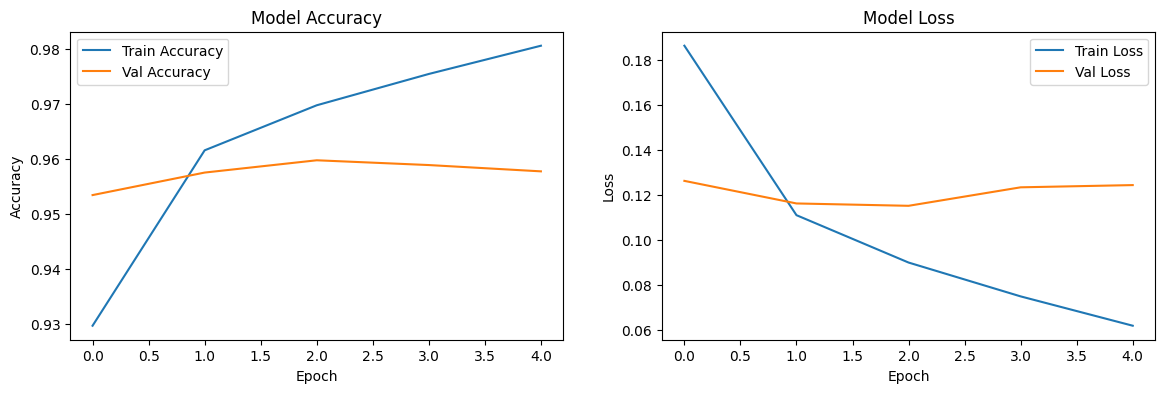

Review: 'These shoes look amazing and fit perfectly. Best purchase ever!'
Sentiment: Positive (Confidence Score: 0.9999)

Review: 'Terrible quality. The fabric ripped after one wash. Do not buy.'
Sentiment: Negative (Confidence Score: 0.0001)

Review: 'It's okay, but honestly a little overpriced for what you get.'
Sentiment: Negative (Confidence Score: 0.0993)



In [37]:
# Cell 7
# Plot Accuracy and Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.show()

# --- Custom Review Tester ---
def predict_sentiment(review_text):
    # Process the raw text into the format the model expects
    seq = tokenizer.texts_to_sequences([review_text])
    padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

    # Predict
    pred = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if pred > 0.5 else "Negative"

    print(f"Review: '{review_text}'")
    print(f"Sentiment: {sentiment} (Confidence Score: {pred:.4f})\n")

# Try it out with your own phrases!
predict_sentiment("These shoes look amazing and fit perfectly. Best purchase ever!")
predict_sentiment("Terrible quality. The fabric ripped after one wash. Do not buy.")
predict_sentiment("It's okay, but honestly a little overpriced for what you get.")